# 📍 DBSCAN (Density-Based Spatial Clustering) 기본 예제

---

## 🎯 1. DBSCAN이란?

DBSCAN은 **밀도 기반 군집화 알고리즘**이다.

👉 핵심 아이디어:

> "데이터가 많이 모여 있는 곳(밀도 높은 곳)을 하나의 군집으로 본다"

---

## 🧠 2. 핵심 개념

### ✔ eps (입실론)

* 한 점 주변을 탐색하는 반경

### ✔ min_samples

* 군집으로 인정하기 위한 최소 데이터 개수

---

## 🌱 3. 데이터 예제

간단한 2차원 데이터:

```python
X = [
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [7, 8],
    [25, 80]  # 노이즈
]
```

👉 2개의 군집 + 1개의 이상치(노이즈)

---

## 🧪 4. Python 코드

```python
from sklearn.cluster import DBSCAN
import numpy as np

# 데이터
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [7, 8],
    [25, 80]
])

# 모델 생성
model = DBSCAN(eps=2, min_samples=2)

# 학습
model.fit(X)

# 결과
labels = model.labels_
print(labels)
```

---

## 📊 5. 결과 해석

예:

```
[0 0 0 1 1 1 -1]
```

### ✔ 의미

| 값  | 의미        |
| -- | --------- |
| 0  | 첫 번째 군집   |
| 1  | 두 번째 군집   |
| -1 | 노이즈 (이상치) |

---

## 🌳 6. 시각화 코드

```python
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("DBSCAN Clustering")
plt.show()
```

---

## 🧠 7. 동작 방식 (직관)

### ① 한 점 선택

### ② eps 안에 몇 개 있는지 확인

### ③ min_samples 이상이면 → 군집 시작

### ④ 연결된 점 계속 확장

---

## 🔥 8. 핵심 특징

### ✔ 장점

* 군집 개수 지정 필요 없음
* 이상치 자동 탐지
* 비선형 구조도 잘 찾음

### ❌ 단점

* eps 설정 민감
* 데이터 밀도 차이 크면 성능 저하

---

## 🚀 9. K-Means와 비교

| 알고리즘    | 특징    |
| ------- | ----- |
| K-Means | 중심 기반 |
| DBSCAN  | 밀도 기반 |

👉 차이 핵심:

* K-Means → 원형 군집
* DBSCAN → 자유로운 모양 군집

---

## 💡 10. 핵심 요약

* 밀도 기반 군집
* eps + min_samples가 핵심
* 노이즈 자동 제거

---

## 🔥 한 줄 정리

> DBSCAN = "데이터가 많이 모인 곳을 자동으로 군집으로 만드는 알고리즘"


In [ ]:
# K-Means는 "몇 개 그룹인지 알고 시작"
# DBSCAN은 "그룹 개수를 몰라도 자동으로 찾음"

# 밀도가 높은 곳 = 군집
# 밀도가 낮은 곳 = 노이즈

# 3가지 개념
# ε (epsilon) : 반경
# min_samples : 최소 데이터 개수
# core point : 중심 데이터
# border point : 경계 데이터
# noise : 이상치

# K-Means
# ↓
# 거리 기반 한계
# ↓
# DBSCAN 등장
# ↓
# 밀도 개념
# ↓
# eps / min_samples 튜닝
# ↓
# 이상치 탐지
# ↓
# 실전 적용

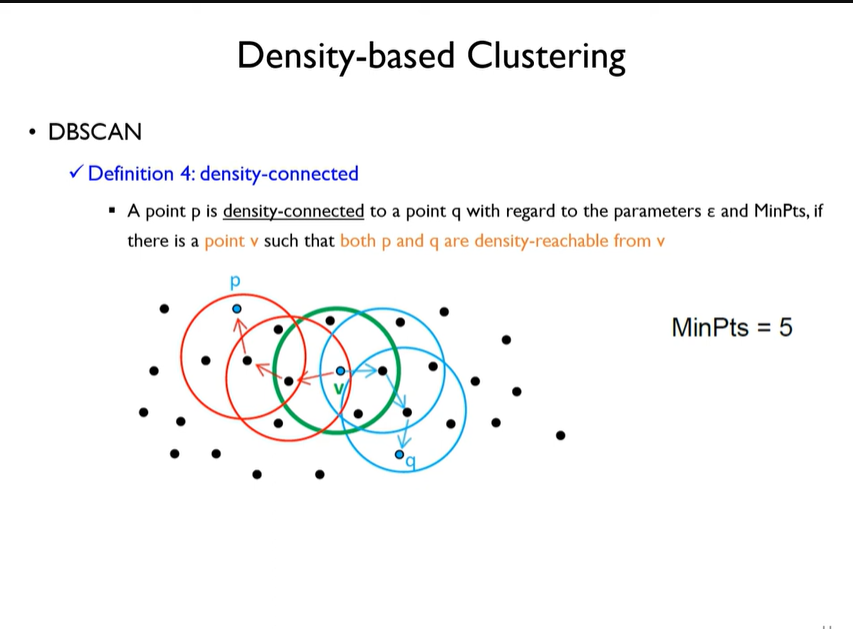

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# 데이터
X = np.array([
    [1, 2], 
    [2, 2], 
    [2, 3],
    [8, 7], 
    [8, 8], 
    [7, 8],
    [25, 80]
])

# 모델 생성
# eps=2 한 점 기준으로 반경 2 안에 있는 점들을 이웃으로 본다
# min_samples=2 이웃이 2개 이상 있어야 군집으로 인정
# "반경 2 안에 친구가 2명 이상 있어야 우리 그룹!"

# 내부에서 하는 일
# 1.한 점 선택(내부 데이터중 하나)
# 2.eps 안에 몇 개 있는지 확인
# 3.min_samples 만족하면 군집 시작
# 4.연결된 점 계속 확장

# 먼저 점 p가 있다고 할때, 점 p에서 부터 거리 e (epsilon)내에 점이 m(minPts) 개 있으면 하나의 군집으로 인식한
# 출처: https://bcho.tistory.com/1205 [조대협의 블로그:티스토리]

model = DBSCAN(eps=2, min_samples=2)

# 학습
model.fit(X)

# 결과
labels = model.labels_
print(labels) #각 데이터의 군집 번호 반환

# ✔ Noise
# 👉 아무 군집에도 속하지 않음

# 🧠 진짜 중요한 핵심
# DBSCAN 성능 = eps 선택이 80%

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("DBSCAN Clustering")
plt.show()

In [ ]:
# eps 영향 분석 (DBSCAN 핵심)

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 비선형 데이터 (DBSCAN에 적합)
X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

plt.scatter(X[:,0], X[:,1])
plt.title("Raw Data")
plt.show()